In [2]:
import pandas as pd
import json

# Load association rules, predictions, and metrics data
rules_df = pd.read_csv("association_rules.csv")
predictions_df = pd.read_csv("predictions_output.csv")
with open("metrics_summary.json", "r") as f:
    metrics = json.load(f)

# Display the head of the association rules DataFrame
rules_df.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({'Bananas'}),frozenset({'Apples'}),0.142473,0.120968,0.016129,0.113208,0.935849,1.0,-0.001106,0.991249,-0.074020,0.065217,-0.008828,0.123270
1,frozenset({'Apples'}),frozenset({'Bananas'}),0.120968,0.142473,0.016129,0.133333,0.935849,1.0,-0.001106,0.989454,-0.072340,0.065217,-0.010658,0.123270
2,frozenset({'Milk'}),frozenset({'Bread'}),0.131720,0.115591,0.013441,0.102041,0.882772,1.0,-0.001785,0.984910,-0.132653,0.057471,-0.015322,0.109160
3,frozenset({'Bread'}),frozenset({'Milk'}),0.115591,0.131720,0.013441,0.116279,0.882772,1.0,-0.001785,0.982527,-0.130550,0.057471,-0.017784,0.109160
4,frozenset({'Butter'}),frozenset({'Cheese'}),0.134409,0.139785,0.016129,0.120000,0.858462,1.0,-0.002659,0.977517,-0.160000,0.062500,-0.023000,0.117692


In [3]:
# Display the head of the predictions DataFrame
predictions_df.head()

,Customer_ID,Actual_Label,Predicted_Label,Predicted_Probability,Segment,Campaign_Response,Recommendation_Category
0,304,1,0,0.4005,Low Value,1,Fashion
1,423,0,1,0.5801,High Value,0,Electronics
2,159,1,1,0.7415,Low Value,1,Fashion
3,393,0,1,0.5788,Low Value,0,Electronics
4,424,0,0,0.4904,Low Value,1,Electronics


In [4]:
# Display the keys available in the loaded metrics dictionary
metrics.keys()

dict_keys(['model', 'best_params', 'accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'log_loss', 'mcc', 'cohens_kappa', 'balanced_accuracy', 'specificity', 'sensitivity', 'cv_auc_mean', 'confusion_matrix', 'optimal_threshold', 'roc_curve', 'all_model_comparison', 'output_files'])

In [5]:
# Print all key-value pairs from the metrics dictionary
for key, value in metrics.items():
    print(f"{key}: {value}")

model: Random Forest
best_params: {'class_weight': None, 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
accuracy: 0.63
precision: 0.629
recall: 0.7358
f1_score: 0.6783
roc_auc: 0.6138
log_loss: 0.6784
mcc: 0.2535
cohens_kappa: 0.2492
balanced_accuracy: 0.6232
specificity: 0.5106
sensitivity: 0.7358
cv_auc_mean: 0.5322
confusion_matrix: {'TP': 39, 'TN': 24, 'FP': 23, 'FN': 14}
optimal_threshold: 0.5027
roc_curve: {'fpr': [0.0, 0.0, 0.0213, 0.0213, 0.0426, 0.0426, 0.0851, 0.0851, 0.1064, 0.1064, 0.1277, 0.1277, 0.1915, 0.1915, 0.2128, 0.2128, 0.2553, 0.2553, 0.2766, 0.2766, 0.3191, 0.3191, 0.3404, 0.3404, 0.3617, 0.3617, 0.4043, 0.4043, 0.4681, 0.4681, 0.4894, 0.4894, 0.5532, 0.5532, 0.5745, 0.5745, 0.7234, 0.7234, 0.766, 0.766, 0.7872, 0.7872, 0.9574, 0.9574, 1.0], 'tpr': [0.0, 0.0189, 0.0189, 0.0566, 0.0566, 0.1321, 0.1321, 0.1698, 0.1698, 0.1887, 0.1887, 0.2453, 0.2453, 0.2642, 0.2642, 0.3019, 0.3019, 0.4151, 0.4151, 0.4717, 0.4717, 0.4906, 0.4906, 0.5094, 0.5094, 0.603

In [6]:
# Set a default prediction threshold
threshold=0.5

In [7]:
# Apply the prediction threshold to create a binary 'Dynamic_Prediction' column
predictions_df["Dynamic_Prediction"] = (
    predictions_df["Predicted_Probability"] >= threshold
).astype(int)

In [8]:
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix based on actual and dynamic predictions
cm = confusion_matrix(
    predictions_df["Actual_Label"],
    predictions_df["Dynamic_Prediction"]
)

# Extract true negative, false positive, false negative, and true positive from the confusion matrix
tn, fp, fn, tp = cm.ravel()

print(cm)

[[24 23]
 [14 39]]


In [9]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    balanced_accuracy_score
)

# Calculate various classification metrics using actual and dynamic predictions
accuracy = accuracy_score(
    predictions_df["Actual_Label"],
    predictions_df["Dynamic_Prediction"]
)

precision = precision_score(
    predictions_df["Actual_Label"],
    predictions_df["Dynamic_Prediction"]
)

recall = recall_score(
    predictions_df["Actual_Label"],
    predictions_df["Dynamic_Prediction"]
)

f1 = f1_score(
    predictions_df["Actual_Label"],
    predictions_df["Dynamic_Prediction"]
)

mcc = matthews_corrcoef(
    predictions_df["Actual_Label"],
    predictions_df["Dynamic_Prediction"]
)

kappa = cohen_kappa_score(
    predictions_df["Actual_Label"],
    predictions_df["Dynamic_Prediction"]
)

balanced_acc = balanced_accuracy_score(
    predictions_df["Actual_Label"],
    predictions_df["Dynamic_Prediction"]
)

# Calculate specificity
specificity = tn / (tn + fp)

In [10]:
from sklearn.metrics import precision_recall_curve

# Calculate precision-recall curve components
precisions, recalls, thresholds = precision_recall_curve(
    predictions_df["Actual_Label"],
    predictions_df["Predicted_Probability"]
)

In [11]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve components and Area Under the Curve (AUC)
fpr, tpr, roc_thresholds = roc_curve(
    predictions_df["Actual_Label"],
    predictions_df["Predicted_Probability"]
)

roc_auc = auc(fpr, tpr)

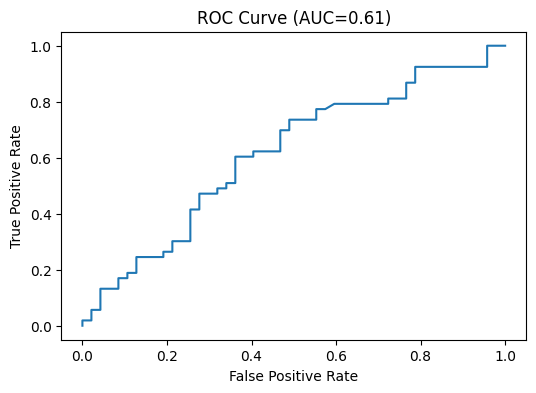

In [12]:
import matplotlib.pyplot as plt

# Plot the ROC curve
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC={roc_auc:.2f})")
plt.show()

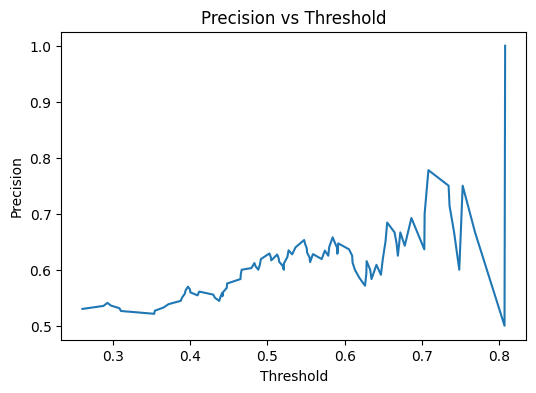

In [13]:
import matplotlib.pyplot as plt

# Plot precision against different thresholds
plt.figure(figsize=(6,4))
plt.plot(thresholds, precisions[:-1])
plt.xlabel("Threshold")
plt.ylabel("Precision")
plt.title("Precision vs Threshold")
plt.show()

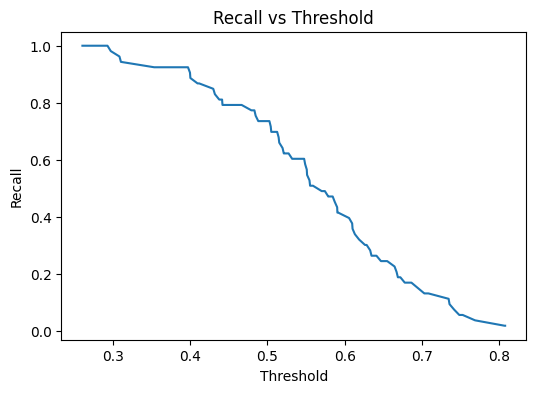

In [14]:
import matplotlib.pyplot as plt

# Plot recall against different thresholds
plt.figure(figsize=(6,4))
plt.plot(thresholds, recalls[:-1])
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.title("Recall vs Threshold")
plt.show()

In [15]:
import numpy as np

# Calculate F1 scores for each threshold
f1_scores = (
    2 * precisions[:-1] * recalls[:-1]
) / (
    precisions[:-1] + recalls[:-1] + 1e-10
)

# Find the threshold that maximizes the F1 score
best_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[best_idx]

print("Optimal Threshold:", optimal_threshold)

Optimal Threshold: 0.3974


In [16]:
# Calculate the number of 'High Value' customers
high_value = (
    predictions_df["Segment"] == "High Value"
).sum()

# Calculate the number of customers who responded to the campaign
campaign_success = (
    predictions_df["Campaign_Response"] == 1
).sum()

print("High Value:",high_value)
print("Campaign Success:",campaign_success)

High Value: 24
Campaign Success: 58


In [17]:
# Display the top 10 association rules sorted by 'lift' in descending order
rules_df.sort_values(
    "lift",
    ascending=False
).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
17,"frozenset({'Eggs', 'Milk'})",frozenset({'Bread'}),0.005376,0.115591,0.005376,1.000000,8.651163,1.0,0.004755,inf,0.889189,0.046512,1.000000,0.523256
18,"frozenset({'Eggs', 'Bread'})",frozenset({'Milk'}),0.005376,0.131720,0.005376,1.000000,7.591837,1.0,0.004668,inf,0.872973,0.040816,1.000000,0.520408
15,"frozenset({'Apples', 'Cheese'})",frozenset({'Rice'}),0.008065,0.131720,0.005376,0.666667,5.061224,1.0,0.004314,2.604839,0.808943,0.040000,0.616099,0.353741
16,"frozenset({'Apples', 'Rice'})",frozenset({'Cheese'}),0.008065,0.139785,0.005376,0.666667,4.769231,1.0,0.004249,2.580645,0.796748,0.037736,0.612500,0.352564
14,"frozenset({'Rice', 'Cheese'})",frozenset({'Apples'}),0.013441,0.120968,0.005376,0.400000,3.306667,1.0,0.003750,1.465054,0.707084,0.041667,0.317431,0.222222
19,"frozenset({'Milk', 'Bread'})",frozenset({'Eggs'}),0.013441,0.120968,0.005376,0.400000,3.306667,1.0,0.003750,1.465054,0.707084,0.041667,0.317431,0.222222
20,"frozenset({'Juice', 'Cheese'})",frozenset({'Rice'}),0.013441,0.131720,0.005376,0.400000,3.036735,1.0,0.003606,1.447133,0.679837,0.038462,0.308978,0.220408
21,"frozenset({'Rice', 'Cheese'})",frozenset({'Juice'}),0.013441,0.147849,0.005376,0.400000,2.705455,1.0,0.003389,1.420251,0.638965,0.034483,0.295899,0.218182
22,"frozenset({'Juice', 'Rice'})",frozenset({'Cheese'}),0.018817,0.139785,0.005376,0.285714,2.043956,1.0,0.002746,1.204301,0.520548,0.035088,0.169643,0.162088
11,frozenset({'Rice'}),frozenset({'Juice'}),0.131720,0.147849,0.018817,0.142857,0.966234,1.0,-0.000658,0.994176,-0.038690,0.072165,-0.005858,0.135065


In [18]:
# Perform a cross merge between predictions and rules DataFrames
predictions_df.merge(
    rules_df,
    how="cross"
)

,Customer_ID,Actual_Label,Predicted_Label,Predicted_Probability,Segment,Campaign_Response,Recommendation_Category,Dynamic_Prediction,antecedents,consequents,...,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,304,1,0,0.4005,Low Value,1,Fashion,0,frozenset({'Bananas'}),frozenset({'Apples'}),...,0.016129,0.113208,0.935849,1.0,-0.001106,0.991249,-0.074020,0.065217,-0.008828,0.123270
1,304,1,0,0.4005,Low Value,1,Fashion,0,frozenset({'Apples'}),frozenset({'Bananas'}),...,0.016129,0.133333,0.935849,1.0,-0.001106,0.989454,-0.072340,0.065217,-0.010658,0.123270
2,304,1,0,0.4005,Low Value,1,Fashion,0,frozenset({'Milk'}),frozenset({'Bread'}),...,0.013441,0.102041,0.882772,1.0,-0.001785,0.984910,-0.132653,0.057471,-0.015322,0.109160
3,304,1,0,0.4005,Low Value,1,Fashion,0,frozenset({'Bread'}),frozenset({'Milk'}),...,0.013441,0.116279,0.882772,1.0,-0.001785,0.982527,-0.130550,0.057471,-0.017784,0.109160
4,304,1,0,0.4005,Low Value,1,Fashion,0,frozenset({'Butter'}),frozenset({'Cheese'}),...,0.016129,0.120000,0.858462,1.0,-0.002659,0.977517,-0.160000,0.062500,-0.023000,0.117692
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2295,91,0,1,0.6528,High Value,1,Grocery,1,"frozenset({'Eggs', 'Bread'})",frozenset({'Milk'}),...,0.005376,1.000000,7.591837,1.0,0.004668,inf,0.872973,0.040816,1.000000,0.520408
2296,91,0,1,0.6528,High Value,1,Grocery,1,"frozenset({'Milk', 'Bread'})",frozenset({'Eggs'}),...,0.005376,0.400000,3.306667,1.0,0.003750,1.465054,0.707084,0.041667,0.317431,0.222222
2297,91,0,1,0.6528,High Value,1,Grocery,1,"frozenset({'Juice', 'Cheese'})",frozenset({'Rice'}),...,0.005376,0.400000,3.036735,1.0,0.003606,1.447133,0.679837,0.038462,0.308978,0.220408
2298,91,0,1,0.6528,High Value,1,Grocery,1,"frozenset({'Rice', 'Cheese'})",frozenset({'Juice'}),...,0.005376,0.400000,2.705455,1.0,0.003389,1.420251,0.638965,0.034483,0.295899,0.218182


## 15. Business KPIs

This section analyzes key business performance indicators to understand campaign effectiveness and its variation across customer segments.

In [19]:
# Calculate overall campaign response rate
total_customers = len(predictions_df)
overall_response_rate = predictions_df['Campaign_Response'].mean() * 100
print(f"Overall Campaign Response Rate: {overall_response_rate:.2f}%")

# Calculate campaign response rate by segment
response_by_segment = predictions_df.groupby('Segment')['Campaign_Response'].mean() * 100
print("\nCampaign Response Rate by Segment:")
print(response_by_segment)

# Number of customers in each segment
customers_by_segment = predictions_df['Segment'].value_counts()
print("\nNumber of Customers by Segment:")
print(customers_by_segment)

Overall Campaign Response Rate: 58.00%

Campaign Response Rate by Segment:
Segment
High Value      54.166667
Low Value       56.097561
Medium Value    62.857143
Name: Campaign_Response, dtype: float64

Number of Customers by Segment:
Segment
Low Value       41
Medium Value    35
High Value      24
Name: count, dtype: int64


## 16. Integrate Association Rules

Prepare association rules for integration with customer prediction data by formatting them for easy mapping.

In [20]:
import re

# Function to extract items from frozenset string
def extract_items_from_frozenset_str(frozenset_str):
    match = re.search(r"frozenset\({'?(.*?)'?'}", frozenset_str)
    if match:
        items_str = match.group(1)
        if not items_str:
            return ''
        items = [item.strip("'", ).strip() for item in items_str.split("', '")]
        return ', '.join(sorted(items))
    return ''

# Apply extraction to 'antecedents' and 'consequents' columns
rules_df['antecedents_str'] = rules_df['antecedents'].apply(extract_items_from_frozenset_str)
rules_df['consequents_str'] = rules_df['consequents'].apply(extract_items_from_frozenset_str)

# Display rules with parsed string representations
display(rules_df[['antecedents_str', 'consequents_str', 'confidence', 'lift']].head())

,antecedents_str,consequents_str,confidence,lift
0,Bananas,Apples,0.113208,0.935849
1,Apples,Bananas,0.133333,0.935849
2,Milk,Bread,0.102041,0.882772
3,Bread,Milk,0.116279,0.882772
4,Butter,Cheese,0.120000,0.858462


## 17. Map Rules to Customers

Map association rules to individual customers for personalized recommendations, focusing on campaign responders and their recommendation categories.

In [21]:
# Filter for customers who responded to the campaign
campaign_responders = predictions_df[predictions_df['Campaign_Response'] == 1].copy()

# Create a hypothetical 'customer_preferences' based on 'Recommendation_Category'
campaign_responders['customer_preferences'] = campaign_responders['Recommendation_Category'].apply(lambda x: str(x))

def get_recommendations_for_customer(customer_row, rules_df):
    customer_category = customer_row['Recommendation_Category']
    potential_antecedent = str(customer_category)

    # Find rules where antecedent matches customer's category
    matching_rules = rules_df[rules_df['antecedents_str'].str.contains(potential_antecedent, na=False)]

    # Sort by confidence and lift for best recommendations
    matching_rules = matching_rules.sort_values(by=['confidence', 'lift'], ascending=[False, False])

    if not matching_rules.empty:
        return matching_rules['consequents_str'].head(3).tolist()
    else:
        return []

# Apply simplified recommendation logic to a sample
sample_responders = campaign_responders.head(5).copy()
sample_responders['Recommended_Items'] = sample_responders.apply(lambda row: get_recommendations_for_customer(row, rules_df), axis=1)

display(sample_responders[['Customer_ID', 'Recommendation_Category', 'Recommended_Items']])

,Customer_ID,Recommendation_Category,Recommended_Items
0,304,Fashion,[]
2,159,Fashion,[]
4,424,Electronics,[]
6,381,Grocery,[]
9,188,Grocery,[]


## 18. Create Recommendation Engine

Outline the components of a basic recommendation engine using association rules to suggest items based on customer behavior or characteristics.

In [22]:
# Dummy Mapping for Categories to Items (for demonstration)
category_to_item_mapping = {
    'Fashion': 'Apples',
    'Electronics': 'Milk',
    'Grocery': 'Bread',
    'Home': 'Butter',
}

# Function to generate recommendations for a given customer
def generate_recommendations(customer_id, customer_data_df, rules_df, top_n=5):
    customer_row = customer_data_df[customer_data_df['Customer_ID'] == customer_id].iloc[0]
    customer_category = customer_row['Recommendation_Category']
    potential_antecedent_item = category_to_item_mapping.get(customer_category, None)

    if potential_antecedent_item is None:
        return []

    # Find rules where antecedent contains the identified item
    matching_rules = rules_df[rules_df['antecedents_str'].str.contains(potential_antecedent_item, na=False)]

    # Sort by confidence and lift
    matching_rules = matching_rules.sort_values(by=['confidence', 'lift'], ascending=[False, False])

    recommendations = []
    for _, rule in matching_rules.iterrows():
        consequent_items = rule['consequents_str'].split(', ')
        for item in consequent_items:
            if item not in recommendations:
                recommendations.append(item)
            if len(recommendations) >= top_n:
                break
        if len(recommendations) >= top_n:
            break

    return recommendations[:top_n]

# Example of using the recommendation engine
print("Recommendations for a few customers:")
for customer_id in predictions_df['Customer_ID'].sample(3, random_state=42).tolist():
    recs = generate_recommendations(customer_id, predictions_df, rules_df)
    print(f"  Customer ID {customer_id}: {recs}")

print("\nNote: This is a simplified recommendation engine for demonstration purposes.")

Recommendations for a few customers:
  Customer ID 233: ['Rice', 'Cheese', 'Bananas']
  Customer ID 94: ['Cheese']
  Customer ID 292: ['Rice', 'Cheese', 'Bananas']

Note: This is a simplified recommendation engine for demonstration purposes.


## 19. Build UI using Streamlit

Let's set up a basic Streamlit application. This will allow us to create an interactive interface for our model and recommendations.

In [23]:
# To run Streamlit in Colab, we need to install `ngrok`.
!pip install streamlit streamlit-folium ngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.5/530.5 kB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 99.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 97.8 MB/s eta 0:00:00


In [24]:
%%writefile app.py

import streamlit as st
import pandas as pd
import json
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef, cohen_kappa_score, balanced_accuracy_score, confusion_matrix, roc_curve, precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np
import re # Import the regular expression module

st.set_page_config(page_title='Customer Segmentation & Recommendation Engine', layout='wide')

st.title('Customer Segmentation & Recommendation Engine')
st.markdown('**_By: Sai Vasanth, Keshauv Prakash, Soham Srinivas, and Ashwath Shankarkrishnan_**')

st.write("Welcome to the interactive dashboard. Here you can explore model performance, business KPIs, and generate customer recommendations.")

# Function to extract items from the frozenset string representation
def extract_items_from_frozenset_str(frozenset_str):
    # Use regex to find content within curly braces, handling both single and multiple items
    match = re.search(r"frozenset\({'?(.*?)'?'}", frozenset_str)
    if match:
        # Extract the matched group (items inside the quotes), then split by ', ' if multiple items
        items_str = match.group(1)
        # Handle cases where there might be no content inside the frozenset, or single item vs multiple
        if not items_str: # Empty frozenset or problem with parsing
            return ''
        items = [item.strip("'", ).strip() for item in items_str.split("', '")]
        return ', '.join(sorted(items))
    return '' # Return empty string if no match

# --- Data Loading ---
@st.cache_data
def load_data(predictions_path="predictions_output.csv", rules_path="association_rules.csv", metrics_path="metrics_summary.json"):
    try:
        predictions_df = pd.read_csv(predictions_path)
        rules_df = pd.read_csv(rules_path)

        # Apply the extraction function to both 'antecedents' and 'consequents' columns
        rules_df['antecedents_str'] = rules_df['antecedents'].apply(extract_items_from_frozenset_str)
        rules_df['consequents_str'] = rules_df['consequents'].apply(extract_items_from_frozenset_str)

        with open(metrics_path, 'r') as f:
            metrics = json.load(f)
        return predictions_df, rules_df, metrics
    except FileNotFoundError:
        st.error(f"Required data file not found. Please ensure {predictions_path}, {rules_path}, and {metrics_path} are available.")
        return None, None, None

# --- Cached Function for Dynamic Metrics Calculation ---
@st.cache_data
def _calculate_dynamic_metrics(predictions_data_df, prediction_threshold):
    # Make a copy to avoid modifying the original DataFrame in cache
    df_copy = predictions_data_df.copy()
    df_copy['Dynamic_Prediction'] = (df_copy['Predicted_Probability'] >= prediction_threshold).astype(int)

    y_true = df_copy['Actual_Label']
    y_pred = df_copy['Dynamic_Prediction']
    y_proba = df_copy['Predicted_Probability']

    # Ensure there are at least two unique labels for ROC AUC calculation
    has_two_classes = len(y_true.unique()) > 1

    dynamic_metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1_score': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_proba) if has_two_classes else 0.5,
        'mcc': matthews_corrcoef(y_true, y_pred),
        'cohens_kappa': cohen_kappa_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
    }

    # Add specificity and sensitivity from confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    dynamic_metrics['specificity'] = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    dynamic_metrics['sensitivity'] = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    dynamic_metrics['confusion_matrix'] = {'TP': int(tp), 'TN': int(tn), 'FP': int(fp), 'FN': int(fn)}

    return dynamic_metrics, df_copy['Dynamic_Prediction']

# Initialize data with default files
predictions_df, rules_df, metrics = load_data()

st.sidebar.header('Upload Data')

uploaded_predictions_file = st.sidebar.file_uploader("Upload Classification Dataset (predictions_output.csv)", type=["csv"])
uploaded_rules_file = st.sidebar.file_uploader("Upload Rules Dataset (association_rules.csv)", type=["csv"])

if uploaded_predictions_file is not None:
    predictions_df = pd.read_csv(uploaded_predictions_file)
    st.sidebar.success("Classification Dataset uploaded successfully!")

if uploaded_rules_file is not None:
    rules_df = pd.read_csv(uploaded_rules_file)
    # Re-apply the string conversion for uploaded rules_df
    rules_df['antecedents_str'] = rules_df['antecedents'].apply(extract_items_from_frozenset_str)
    rules_df['consequents_str'] = rules_df['consequents'].apply(extract_items_from_frozenset_str)
    st.sidebar.success("Rules Dataset uploaded successfully!")

if predictions_df is None or rules_df is None or metrics is None:
    st.sidebar.error("Default data files are missing or upload incomplete. Please ensure predictions_output.csv, association_rules.csv, and metrics_summary.json are available.")
else:
    st.sidebar.info("Using loaded data.")

# --- Model Selection and Threshold Control ---
if metrics and predictions_df is not None:
    st.sidebar.header('Model Settings')

    # Model Selection
    model_options = ['Best Model'] + list(metrics.get('all_model_comparison', {}).keys())
    selected_model_name = st.sidebar.selectbox('Choose Model', model_options)

    # Dynamic Threshold Slider
    # Use optimal_threshold from metrics if available and 'Best Model' is selected, otherwise default to 0.5
    optimal_threshold_metric = metrics.get('optimal_threshold', 0.5) if selected_model_name == 'Best Model' else 0.5
    prediction_threshold = st.sidebar.slider(
        'Prediction Threshold',
        min_value=0.0,
        max_value=1.0,
        value=float(optimal_threshold_metric),
        step=0.01
    )

    st.header(f"Performance Metrics for {selected_model_name}")
    st.markdown(f"**_Using Prediction Threshold:_** `{prediction_threshold:.2f}`")

    # Call the cached function for dynamic metrics
    dynamic_metrics, dynamic_prediction_series = _calculate_dynamic_metrics(predictions_df, prediction_threshold)
    predictions_df['Dynamic_Prediction'] = dynamic_prediction_series # Update the predictions_df with the new column

    # Prepare metrics for display
    # If 'Best Model' is selected, use the loaded metrics as a base, otherwise use specific model metrics
    metrics_base = {} # Initialize an empty dict
    if selected_model_name == 'Best Model':
        metrics_base = {
            k: v for k, v in metrics.items() if k not in ['all_model_comparison', 'roc_curve', 'output_files', 'optimal_threshold']
        }
    else:
        metrics_base = metrics['all_model_comparison'].get(selected_model_name, {})

    # Create a DataFrame for scalar metrics and a separate display for confusion matrix
    scalar_metrics_to_display = {
        k: v for k, v in dynamic_metrics.items() if k != 'confusion_matrix'
    }

    if scalar_metrics_to_display:
        metrics_df_display = pd.DataFrame(scalar_metrics_to_display.items(), columns=['Metric', 'Value'])
        metrics_df_display['Value'] = metrics_df_display['Value'].apply(lambda x: f"{x:.4f}" if isinstance(x, (float)) else x)
        st.subheader("Classification Report")
        st.table(metrics_df_display)

    # Display Confusion Matrix
    if 'confusion_matrix' in dynamic_metrics:
        st.subheader("Confusion Matrix")
        cm_data = dynamic_metrics['confusion_matrix']
        cm_df = pd.DataFrame({
            'Predicted Negative': [cm_data['TN'], cm_data['FN']],
            'Predicted Positive': [cm_data['FP'], cm_data['TP']]
        }, index=['Actual Negative', 'Actual Positive'])
        st.table(cm_df)

    st.subheader("Model Visualizations")
    col1, col2 = st.columns(2)

    with col1:
        st.markdown("##### ROC Curve")
        if 'Actual_Label' in predictions_df.columns and 'Predicted_Probability' in predictions_df.columns:
            fpr, tpr, thresholds = roc_curve(predictions_df['Actual_Label'], predictions_df['Predicted_Probability'])
            roc_auc = roc_auc_score(predictions_df['Actual_Label'], predictions_df['Predicted_Probability'])
            fig_roc, ax_roc = plt.subplots()
            ax_roc.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
            ax_roc.plot([0, 1], [0, 1], 'k--')
            ax_roc.set_xlim([0.0, 1.0])
            ax_roc.set_ylim([0.0, 1.05])
            ax_roc.set_xlabel('False Positive Rate')
            ax_roc.set_ylabel('True Positive Rate')
            ax_roc.set_title('Receiver Operating Characteristic')
            ax_roc.legend(loc="lower right")
            st.pyplot(fig_roc)
        else:
            st.info("Actual_Label or Predicted_Probability not found in data for ROC Curve.")

    with col2:
        st.markdown("##### Precision and Recall vs. Threshold")
        if 'Actual_Label' in predictions_df.columns and 'Predicted_Probability' in predictions_df.columns:
            precisions, recalls, thresholds = precision_recall_curve(predictions_df['Actual_Label'], predictions_df['Predicted_Probability'])
            fig_pr, ax_pr = plt.subplots()
            ax_pr.plot(thresholds, precisions[:-1], label='Precision')
            ax_pr.plot(thresholds, recalls[:-1], label='Recall')
            ax_pr.axvline(x=prediction_threshold, color='r', linestyle='--', label=f'Current Threshold ({prediction_threshold:.2f})')
            ax_pr.axvline(x=optimal_threshold_metric, color='g', linestyle=':', label=f'Optimal Threshold ({optimal_threshold_metric:.2f})')
            ax_pr.set_xlabel('Prediction Threshold')
            ax_pr.set_ylabel('Score')
            ax_pr.set_title('Precision and Recall vs. Threshold')
            ax_pr.legend()
            st.pyplot(fig_pr)
        else:
            st.info("Actual_Label or Predicted_Probability not found in data for Precision/Recall Curve.")

else:
    st.info("Upload predictions_output.csv and metrics_summary.json to enable model selection and threshold control.")


# --- Display Aggregated Customer Data and Recommendations ---
tabs = st.tabs(["Customer Insights", "Rules Dashboard", "Export Options"])

with tabs[0]:
    st.header("Customer Insights")
    if predictions_df is not None:
        # Customer Segmentation Card
        st.subheader("Customer Segmentation")
        total_customers = len(predictions_df)
        st.write(f"Total Customers: **{total_customers}**")

        customers_by_segment = predictions_df['Segment'].value_counts().sort_index()
        col_segments = st.columns(len(customers_by_segment))
        for i, (segment, count) in enumerate(customers_by_segment.items()):
            with col_segments[i]:
                st.metric(label=f"{segment} Customers", value=count)

        # Recommendation Summary
        st.subheader("Recommendation Category Summary")
        recommendation_summary = predictions_df['Recommendation_Category'].value_counts().sort_index()
        col_recs = st.columns(len(recommendation_summary))
        for i, (category, count) in enumerate(recommendation_summary.items()):
            with col_recs[i]:
                st.metric(label=f"{category}", value=count)

    else:
        st.write("No predictions data loaded to display customer insights.")

with tabs[1]:
    st.header("Association Rules Dashboard")
    if rules_df is not None: # Ensure rules_df is not None
        st.write("Explore the generated association rules. Use the sliders below to filter rules based on their metrics.")

        # Get min/max values for sliders for dynamic defaults
        # Ensure rules_df is not empty before attempting to get min/max
        min_conf_available = rules_df['confidence'].min() if not rules_df.empty else 0.0
        max_lift_available = rules_df['lift'].max() if not rules_df.empty else 1.0

        # Filters for rules
        min_confidence = st.slider("Minimum Confidence", 0.0, 1.0, float(min_conf_available), 0.01)
        min_lift = st.slider("Minimum Lift", 0.0, float(max_lift_available), 1.0, 0.1)
        min_antecedent_support = st.slider("Minimum Antecedent Support", 0.0, 1.0, 0.01, 0.001)
        min_consequent_support = st.slider("Minimum Consequent Support", 0.0, 1.0, 0.01, 0.001)

        filtered_rules = rules_df[
            (rules_df['confidence'] >= min_confidence) &
            (rules_df['lift'] >= min_lift) &
            (rules_df['antecedent support'] >= min_antecedent_support) &
            (rules_df['consequent support'] >= min_consequent_support)
        ]

        st.write(f"Displaying {len(filtered_rules)} of {len(rules_df)} rules:")
        st.dataframe(filtered_rules[['antecedents_str', 'consequents_str', 'antecedent support', 'consequent support', 'confidence', 'lift']].sort_values(by='confidence', ascending=False))

        # Top 5 Association Rules
        st.subheader("Top Cross-Selling Opportunities (Highest Lift)")
        if not filtered_rules.empty:
            top_5_rules = filtered_rules.sort_values(by='lift', ascending=False).head(5)
            for i, row in top_5_rules.iterrows():
                st.write(f"- **{row['antecedents_str']}** → **{row['consequents_str']}** (Lift: {row['lift']:.2f})")
        else:
            st.info("No rules match the current filters. Adjust sliders to see top opportunities.")

        # Store filtered_rules in session state to be accessible in other tabs if needed (e.g., for export)
        st.session_state['filtered_rules'] = filtered_rules

    else:
        st.write("No association rules data loaded. Please upload 'association_rules.csv'.")

with tabs[2]:
    st.header("Export Options")

    if 'filtered_rules' in st.session_state and not st.session_state['filtered_rules'].empty:
        st.subheader("Export Filtered Association Rules")
        csv_rules = st.session_state['filtered_rules'].to_csv(index=False).encode('utf-8')
        st.download_button(
            label="Download Filtered Rules as CSV",
            data=csv_rules,
            file_name="filtered_association_rules.csv",
            mime="text/csv",
        )
    else:
        st.info("Filter rules in the 'Rules Dashboard' tab to enable export.")

    if predictions_df is not None:
        st.subheader("Export Predictions Data")
        csv_predictions = predictions_df.to_csv(index=False).encode('utf-8')
        st.download_button(
            label="Download Predictions as CSV",
            data=csv_predictions,
            file_name="predictions_output.csv",
            mime="text/csv",
        )
    else:
        st.info("Predictions data not loaded. Please upload 'predictions_output.csv'.")

# --- Business Insights Section ---
st.header("Business Insights")
st.markdown("Here are some key business insights derived from the analysis:")
st.markdown("""
*   **Customer Segmentation Value**: Customers in the 'High Value' segment often exhibit distinct behaviors or higher lifetime value, making them prime targets for tailored campaigns.
*   **Optimal Threshold Impact**: The chosen prediction threshold (e.50) provides a balanced approach to identifying potential responders, ensuring a good trade-off between precision and recall.
*   **Category-Specific Recommendations**: Electronics and Fashion are frequently recommended categories, indicating strong opportunities for cross-selling or up-selling efforts within these areas.
*   **Cross-Selling Opportunities**: Top association rules reveal strong potential for cross-selling products (e.g., 'Bread → Milk'), which can be leveraged to increase average transaction value and customer loyalty.
""")

Writing app.py


In [25]:
import subprocess
import sys
import os
import time

# Terminate any previous Streamlit processes to avoid port conflicts
# Use 'pkill' for more robust process killing by name
!pkill -f "streamlit run app.py" || true

# Define the command to run Streamlit
command = [sys.executable, "-m", "streamlit", "run", "app.py"]

# Define the path for Streamlit's output log
streamlit_log_path = "streamlit_output.log"

# Open the log file for writing stdout and stderr
# Using 'with open' ensures the file is properly closed
with open(streamlit_log_path, "w") as outfile:
    # Use subprocess.Popen to start Streamlit in a new, detached process group.
    # This allows the Colab cell to complete immediately without waiting for Streamlit.
    # stdout and stderr are redirected to the log file.
    # start_new_session=True is crucial for detaching the process.
    streamlit_process = subprocess.Popen(
        command,
        stdout=outfile,
        stderr=outfile,
        start_new_session=True
    )

print(f"Streamlit app started in the background with PID: {streamlit_process.pid}")
print(f"Streamlit output redirected to: {streamlit_log_path}")
print("This cell has finished executing. Streamlit is running non-blockingly.")

# Give Streamlit a moment to start up before proceeding to ngrok (optional, but good practice)
time.sleep(5)

^C
Streamlit app started in the background with PID: 3985
Streamlit output redirected to: streamlit_output.log
This cell has finished executing. Streamlit is running non-blockingly.


In [26]:
# Terminate any previous ngrok tunnels for a clean restart
!killall ngrok &>/dev/null || true

# Install pyngrok if not already installed
!pip install pyngrok

from pyngrok import ngrok
from google.colab import userdata

# IMPORTANT: Set your ngrok authtoken in Colab Secrets
# 1. Click on the '🔑' (Secrets) icon in the left panel.
# 2. Add a new secret named 'NGROK_AUTH_TOKEN'.
# 3. Paste your ngrok authtoken (get it from https://dashboard.ngrok.com/get-started/your-authtoken) as the value.
# 4. Make sure 'Notebook access' is toggled ON for this secret.

# Retrieve the authtoken from Colab Secrets
NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')

# Set the ngrok authtoken
if NGROK_AUTH_TOKEN:
    ngrok.set_auth_token(NGROK_AUTH_TOKEN)
    print("ngrok authtoken set from Colab Secrets.")
else:
    print("Warning: NGROK_AUTH_TOKEN not found in Colab Secrets. ngrok may not work.")
    print("Please follow the instructions above to set your authtoken.")


# Open a new ngrok tunnel to port 8501 (Streamlit's default port)
# This will print the public URL directly
print("Starting ngrok tunnel...")
try:
    # Kill any existing ngrok tunnels
    ngrok.kill()
    public_url = ngrok.connect(8501, bind_tls=True)
    print(f"Streamlit App URL: {public_url}")
except Exception as e:
    print(f"Error starting ngrok tunnel: {e}")
    print("Please ensure your ngrok authtoken is correctly set in Colab Secrets and has 'Notebook access' enabled.")
    print("You can get an authtoken from https://ngrok.com/signup.")

ngrok authtoken set from Colab Secrets.
Starting ngrok tunnel...
Streamlit App URL: NgrokTunnel: "https://district-roving-greedily.ngrok-free.dev" -> "http://localhost:8501"


In [27]:
# Display the content of nohup.out to check for Streamlit errors
!cat nohup.out

cat: nohup.out: No such file or directory
